# PTB-XL → MIT-BIH-Style Preprocessing Notebook

Goal: transform PTB-XL records into **single-lead, fixed-length heartbeat segments** similar to MIT-BIH heartbeat CSV style.

Main transformations:
- Use one lead (Lead II)
- Detect peaks and extract beat windows
- Fixed beat length = 187 samples (zero-padded if needed)
- Per-beat min-max normalization to [0, 1]
- Save train/val/test arrays for 1D-CNN training

In [1]:
import json
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import wfdb
from scipy.signal import find_peaks

print('Imports OK')

Imports OK


In [2]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'phase1':
    PROJECT_ROOT = PROJECT_ROOT.parent.parent
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / 'dataset' / 'raw' / 'ptb-xl'
OUT_DIR = PROJECT_ROOT / 'dataset' / 'processed' / 'ptbxl_mit_style'
OUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = RAW_DIR / 'ptbxl_database.csv'
SCP_PATH = RAW_DIR / 'scp_statements.csv'

SEED = 42
SR = 100
BEAT_LEN = 187
PRE_SAMPLES = 60
POST_SAMPLES = BEAT_LEN - PRE_SAMPLES
MAX_BEATS_PER_RECORD = 40
MAX_RECORDS = 0  # 0 = all

print('PROJECT_ROOT:', PROJECT_ROOT)
print('RAW_DIR exists:', RAW_DIR.exists())
print('OUT_DIR:', OUT_DIR)

PROJECT_ROOT: /Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence
RAW_DIR exists: True
OUT_DIR: /Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence/dataset/processed/ptbxl_mit_style


In [3]:
df = pd.read_csv(CSV_PATH, index_col='ecg_id')
scp_df = pd.read_csv(SCP_PATH, index_col=0)

diag_map = scp_df[scp_df['diagnostic'] == 1]['diagnostic_class'].dropna().to_dict()

def parse_scp_codes(value):
    if isinstance(value, str):
        return ast.literal_eval(value)
    return {}

def map_to_superclasses(code_dict):
    classes = []
    for code in code_dict.keys():
        if code in diag_map:
            classes.append(diag_map[code])
    return sorted(set(classes))

df['scp_codes_dict'] = df['scp_codes'].apply(parse_scp_codes)
df['diagnostic_classes'] = df['scp_codes_dict'].apply(map_to_superclasses)

# Keep only records with exactly one superclass label (single-label classification)
df_single = df[df['diagnostic_classes'].map(len) == 1].copy()
df_single['label_name'] = df_single['diagnostic_classes'].apply(lambda x: x[0])

label_names = sorted(df_single['label_name'].unique().tolist())
label_to_id = {name: i for i, name in enumerate(label_names)}
df_single['label_id'] = df_single['label_name'].map(label_to_id)

print('Records total:', len(df))
print('Records single-label:', len(df_single))
print('Classes:', label_to_id)
display(df_single[['filename_lr', 'label_name', 'label_id']].head(5))

Records total: 21837
Records single-label: 16272
Classes: {'CD': 0, 'HYP': 1, 'MI': 2, 'NORM': 3, 'STTC': 4}


,filename_lr,label_name,label_id
ecg_id,,,
1,records100/00000/00001_lr,NORM,3
2,records100/00000/00002_lr,NORM,3
3,records100/00000/00003_lr,NORM,3
4,records100/00000/00004_lr,NORM,3
5,records100/00000/00005_lr,NORM,3


In [4]:
# Record-level split first (prevents data leakage between beats of same record)
records = df_single.copy()
if MAX_RECORDS > 0:
    records = records.sample(n=min(MAX_RECORDS, len(records)), random_state=SEED)

idx = np.arange(len(records))
labels = records['label_id'].values

idx_train, idx_tmp = train_test_split(idx, test_size=0.30, random_state=SEED, stratify=labels)
idx_val, idx_test = train_test_split(
    idx_tmp,
    test_size=0.50,
    random_state=SEED,
    stratify=labels[idx_tmp],
)

split_records = {
    'train': records.iloc[idx_train],
    'val': records.iloc[idx_val],
    'test': records.iloc[idx_test],
}

for name, part in split_records.items():
    print(name, len(part))

train 11390
val 2441
test 2441


In [5]:
def minmax_per_beat(x):
    x_min = np.min(x)
    x_max = np.max(x)
    if x_max - x_min < 1e-8:
        return np.zeros_like(x, dtype=np.float32)
    return ((x - x_min) / (x_max - x_min)).astype(np.float32)

def pad_or_crop_beat(beat, target_len=187):
    if len(beat) >= target_len:
        return beat[:target_len]
    out = np.zeros(target_len, dtype=np.float32)
    out[:len(beat)] = beat
    return out

def extract_beats_from_record(row, max_beats=40):
    rel_path = row['filename_lr']
    signal, _ = wfdb.rdsamp(str(RAW_DIR / rel_path))

    # Lead II is channel index 1 in PTB-XL
    lead = signal[:, 1].astype(np.float32)

    # Lightweight peak detection for beat centers
    peaks, _ = find_peaks(lead, distance=max(20, int(0.25 * SR)), prominence=np.std(lead) * 0.3)

    beats = []
    for p in peaks[:max_beats]:
        start = p - PRE_SAMPLES
        end = p + POST_SAMPLES

        if start < 0 or end > len(lead):
            beat = lead[max(0, start):min(len(lead), end)]
            beat = pad_or_crop_beat(beat, BEAT_LEN)
        else:
            beat = lead[start:end]

        beat = minmax_per_beat(beat)
        beats.append(beat)

    return beats

In [6]:
def build_split_arrays(records_df, split_name):
    X, y = [], []
    failed = 0

    for _, row in records_df.iterrows():
        try:
            beats = extract_beats_from_record(row, max_beats=MAX_BEATS_PER_RECORD)
            X.extend(beats)
            y.extend([int(row['label_id'])] * len(beats))
        except Exception:
            failed += 1

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.int64)

    print(f'{split_name}: beats={len(X):,}, failed_records={failed}')
    return X, y

X_train, y_train = build_split_arrays(split_records['train'], 'train')
X_val, y_val = build_split_arrays(split_records['val'], 'val')
X_test, y_test = build_split_arrays(split_records['test'], 'test')

train: beats=256,494, failed_records=0
val: beats=54,849, failed_records=0
test: beats=55,005, failed_records=0


In [7]:
print('Shapes:')
print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_val  :', X_val.shape, 'y_val  :', y_val.shape)
print('X_test :', X_test.shape, 'y_test :', y_test.shape)

print('Train value range:', float(X_train.min()), float(X_train.max()))

for split_name, y_split in [('train', y_train), ('val', y_val), ('test', y_test)]:
    uniq, cnt = np.unique(y_split, return_counts=True)
    print(split_name, {label_names[int(i)]: int(c) for i, c in zip(uniq, cnt)})

Shapes:
X_train: (256494, 187) y_train: (256494,)
X_val  : (54849, 187) y_val  : (54849,)
X_test : (55005, 187) y_test : (55005,)
Train value range: 0.0 1.0
train {'CD': 27758, 'HYP': 8103, 'MI': 41778, 'NORM': 139543, 'STTC': 39312}
val {'CD': 5941, 'HYP': 1724, 'MI': 8847, 'NORM': 29863, 'STTC': 8474}
test {'CD': 6111, 'HYP': 1682, 'MI': 8953, 'NORM': 29856, 'STTC': 8403}


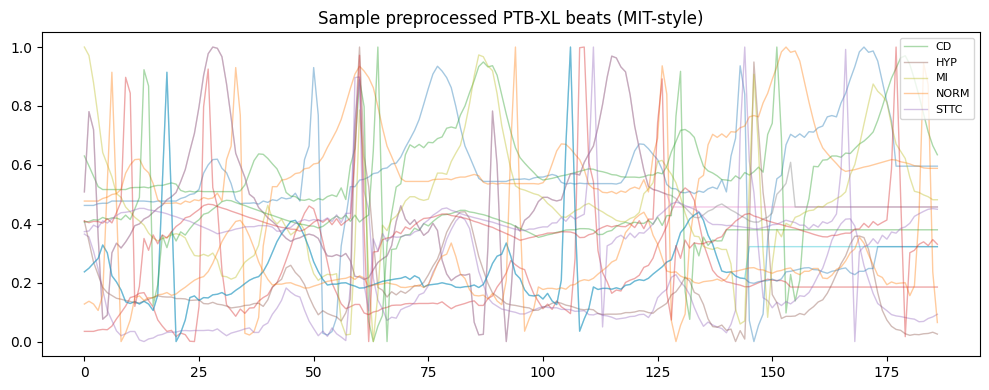

In [8]:
plt.figure(figsize=(10, 4))
for c in sorted(np.unique(y_train))[:5]:
    idx = np.where(y_train == c)[0][:3]
    for j in idx:
        plt.plot(X_train[j], alpha=0.4, lw=1.0, label=label_names[int(c)])

handles, labels = plt.gca().get_legend_handles_labels()
uniq = dict(zip(labels, handles))
plt.legend(uniq.values(), uniq.keys(), fontsize=8)
plt.title('Sample preprocessed PTB-XL beats (MIT-style)')
plt.tight_layout()

In [9]:
out_npz = OUT_DIR / 'ptbxl_mit_style_dataset.npz'
out_meta = OUT_DIR / 'meta.json'

np.savez_compressed(
    out_npz,
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    label_names=np.array(label_names),
)

meta = {
    'sampling_rate': SR,
    'beat_length': BEAT_LEN,
    'single_lead_index': 1,
    'max_beats_per_record': MAX_BEATS_PER_RECORD,
    'max_records': MAX_RECORDS,
    'label_to_id': label_to_id,
    'shapes': {
        'X_train': list(X_train.shape),
        'X_val': list(X_val.shape),
        'X_test': list(X_test.shape),
    },
}
with open(out_meta, 'w') as f:
    json.dump(meta, f, indent=2)

print('Saved:', out_npz)
print('Saved:', out_meta)

Saved: /Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence/dataset/processed/ptbxl_mit_style/ptbxl_mit_style_dataset.npz
Saved: /Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence/dataset/processed/ptbxl_mit_style/meta.json


## What changed vs original PTB-XL pipeline

This notebook shifts PTB-XL toward MIT-BIH-like learning conditions:
- 10-second multi-lead records → single-lead beat segments
- Variable record context → fixed 187-sample heartbeat vectors
- Record-level labels still used, but on beat windows
- Per-beat normalization improves local morphology learning for CNNs